In [14]:
# Imports:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Define the function to be tested
def fcn(x, c):
    return 1/( 1 + c**2 * np.sum( x**2, axis=1 ))

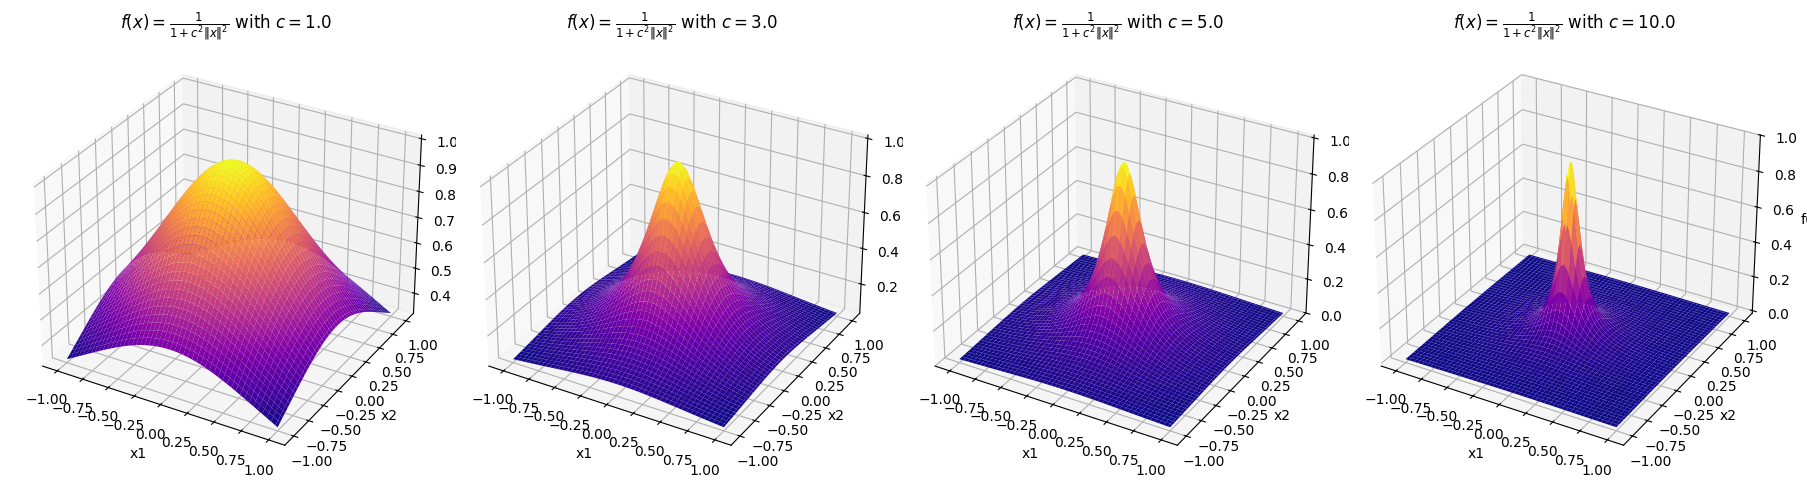

In [16]:
# Generate a grid in 2D
x1 = np.linspace(-1, 1, 100)
x2 = np.linspace(-1, 1, 100)
X1, X2 = np.meshgrid(x1, x2)
X_flat = np.c_[X1.ravel(), X2.ravel()]

# Define multiple values of c
c_values = [1.0, 3.0, 5.0, 10.0]
Z_values = [fcn(X_flat, c).reshape(X1.shape) for c in c_values]

# Create 3D plots for each c
fig = plt.figure(figsize=(18, 18))
for i, (c, Z) in enumerate(zip(c_values, Z_values)):
    ax = fig.add_subplot(1, len(c_values), i+1, projection='3d')
    ax.plot_surface(X1, X2, Z, cmap='plasma', edgecolor='none')
    ax.set_title(rf'$f(x) = \frac{{1}}{{1 + c^2 \|x\|^2}}$' + f' with $c={c}$')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('f(x)')

plt.tight_layout()
plt.show()

In [17]:
def chebyshev_2d_interpolation(N, c, resolution=100):
    kx = np.arange(N+1)
    ky = np.arange(N+1)
    x_nodes = np.cos((2*kx + 1) * np.pi / (2*(N+1)))
    y_nodes = np.cos((2*ky + 1) * np.pi / (2*(N+1)))
    X, Y = np.meshgrid(x_nodes, y_nodes, indexing="ij")
    
    coords = np.stack([X.ravel(), Y.ravel()], axis=1)
    F = fcn(coords, c).reshape((N+1, N+1))

    def chebyshev_polys(x, deg):
        T = np.zeros((deg+1, len(x)))
        T[0] = 1
        if deg > 0:
            T[1] = x
        for k in range(2, deg+1):
            T[k] = 2 * x * T[k-1] - T[k-2]
        return T

    Tx = chebyshev_polys(x_nodes, N)
    Ty = chebyshev_polys(y_nodes, N)
    F_flat = F.T.ravel()
    A = np.kron(Ty.T, Tx.T)
    Q, R = np.linalg.qr(A)
    c_flat = np.linalg.solve(R, Q.T @ F_flat)
    # nan check
    if np.any(np.isnan(c_flat)):
        raise ValueError("NaN values found in the coefficients.")
    # inf check
    if np.any(np.isinf(c_flat)):
        raise ValueError("Inf values found in the coefficients.")
    # determinant check
    if np.linalg.det(R) == 0:
        raise ValueError("Matrix R is singular, cannot solve for coefficients.")
    c = c_flat.reshape((N+1, N+1))

    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    XX, YY = np.meshgrid(xx, yy, indexing="ij")
    Tx_eval = chebyshev_polys(xx, N)
    Ty_eval = chebyshev_polys(yy, N)
    Z = np.zeros_like(XX)
    for i in range(N+1):
        for j in range(N+1):
            Z += c[i, j] * np.outer(Tx_eval[i], Ty_eval[j])
    
    return c, Z

def compute_exact_function_grid(fcn, c, resolution=100):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    XX, YY = np.meshgrid(xx, yy, indexing="ij")

    coords = np.stack([XX.ravel(), YY.ravel()], axis=1)
    F = fcn(coords, c).reshape((resolution, resolution))
    
    return F


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: divide by zero encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: overflow encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: invalid value encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)


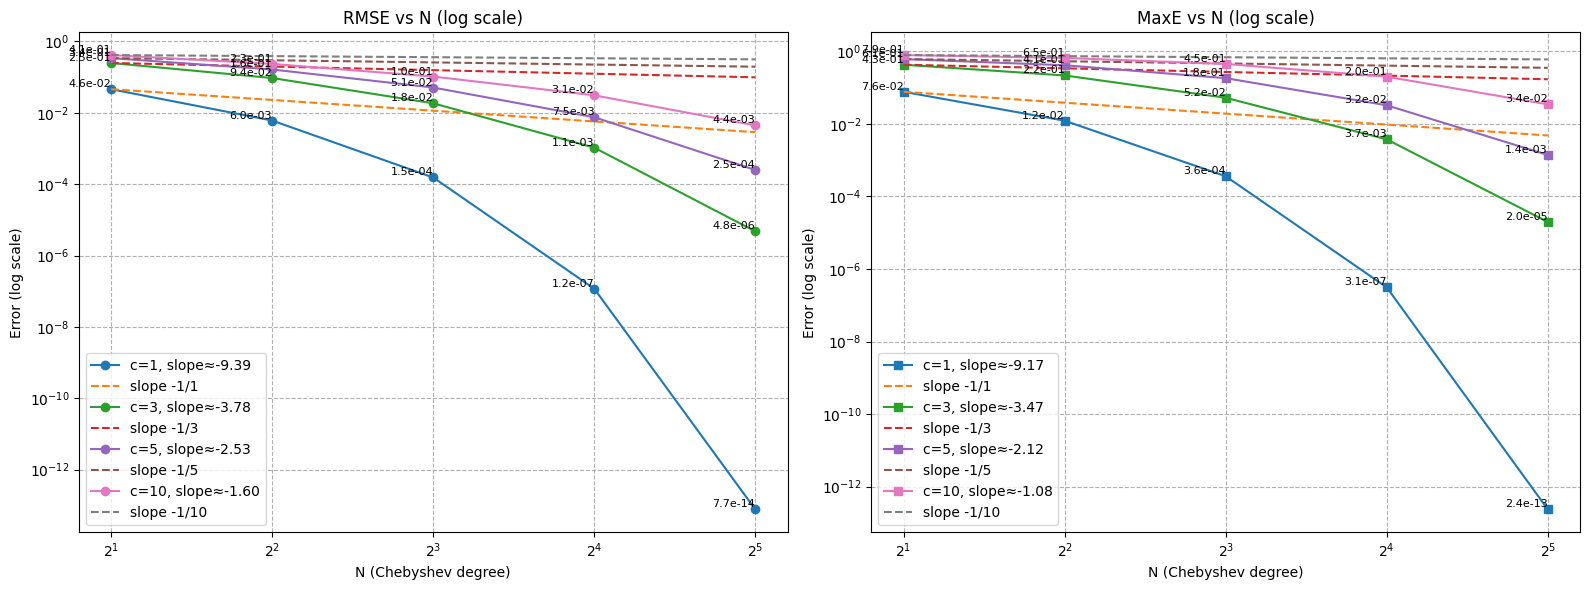

In [18]:
# Config
Ns = [2, 4, 8, 16, 32 ]
    #   , 64, 128]
c_values = [1, 3, 5, 10]

# Prepare plots
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].set_title('RMSE vs N (log scale)')
axs[1].set_title('MaxE vs N (log scale)')

for c in c_values:
    rmse_list = []
    maxe_list = []

    for N in Ns:
        _, Z = chebyshev_2d_interpolation(N, c, resolution=100)
        F = compute_exact_function_grid(fcn, c, resolution=100)

        diff = F - Z
        rmse = np.sqrt(np.mean(diff**2))
        maxe = np.max(np.abs(diff))

        rmse_list.append(rmse)
        maxe_list.append(maxe)

    # Plot RMSE
    axs[0].plot(Ns, rmse_list, marker='o', label=f'c={c}, slope≈{np.polyfit(np.log(Ns), np.log(rmse_list), 1)[0]:.2f}')
    for x, y in zip(Ns, rmse_list):
        axs[0].text(x, y, f'{y:.1e}', fontsize=8, ha='right', va='bottom')

    # Plot MaxE
    axs[1].plot(Ns, maxe_list, marker='s', label=f'c={c}, slope≈{np.polyfit(np.log(Ns), np.log(maxe_list), 1)[0]:.2f}')
    for x, y in zip(Ns, maxe_list):
        axs[1].text(x, y, f'{y:.1e}', fontsize=8, ha='right', va='bottom')

    x_ref = np.array(Ns)
    
    x0 = x_ref[0]
    y0_rmse = rmse_list[0]
    y0_maxe = maxe_list[0]

    ref_rmse = y0_rmse * (x_ref / x0) ** (-1 / c)
    ref_maxe = y0_maxe * (x_ref / x0) ** (-1 / c)

    axs[0].plot(x_ref, ref_rmse, '--', label=f'slope -1/{c}')
    axs[1].plot(x_ref, ref_maxe, '--', label=f'slope -1/{c}')

# Final plot formatting
for ax in axs:
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('N (Chebyshev degree)')
    ax.set_ylabel('Error (log scale)')
    ax.grid(True, which='both', linestyle='--')
    ax.legend()

plt.tight_layout()
plt.show()


Results for c = 1:
N =   2 | RMSE = 4.5672e-02 | MaxE = 7.6358e-02
N =   4 | RMSE = 6.0486e-03 | MaxE = 1.2194e-02
N =   8 | RMSE = 1.5354e-04 | MaxE = 3.5881e-04
N =  16 | RMSE = 1.1747e-07 | MaxE = 3.1082e-07
N =  32 | RMSE = 7.7035e-14 | MaxE = 2.3603e-13


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: divide by zero encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: overflow encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: invalid value encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)


N =  64 | RMSE = 2.8765e-15 | MaxE = 5.6122e-14
N = 128 | RMSE = 1.0563e-14 | MaxE = 5.7887e-13

Results for c = 3:
N =   2 | RMSE = 2.4804e-01 | MaxE = 4.2640e-01
N =   4 | RMSE = 9.4032e-02 | MaxE = 2.1544e-01
N =   8 | RMSE = 1.8418e-02 | MaxE = 5.2248e-02
N =  16 | RMSE = 1.0516e-03 | MaxE = 3.7324e-03
N =  32 | RMSE = 4.7663e-06 | MaxE = 1.9683e-05
N =  64 | RMSE = 1.1428e-10 | MaxE = 5.6225e-10
N = 128 | RMSE = 4.4572e-15 | MaxE = 3.8509e-13

Results for c = 5:
N =   2 | RMSE = 3.3973e-01 | MaxE = 6.0888e-01
N =   4 | RMSE = 1.6291e-01 | MaxE = 4.1178e-01
N =   8 | RMSE = 5.0952e-02 | MaxE = 1.8143e-01
N =  16 | RMSE = 7.4932e-03 | MaxE = 3.2449e-02
N =  32 | RMSE = 2.4914e-04 | MaxE = 1.3824e-03
N =  64 | RMSE = 3.6711e-07 | MaxE = 2.3405e-06
N = 128 | RMSE = 9.5320e-13 | MaxE = 6.9406e-12

Results for c = 10:
N =   2 | RMSE = 4.1378e-01 | MaxE = 7.8632e-01
N =   4 | RMSE = 2.3360e-01 | MaxE = 6.5420e-01
N =   8 | RMSE = 1.0333e-01 | MaxE = 4.4704e-01
N =  16 | RMSE = 3.0851e-02

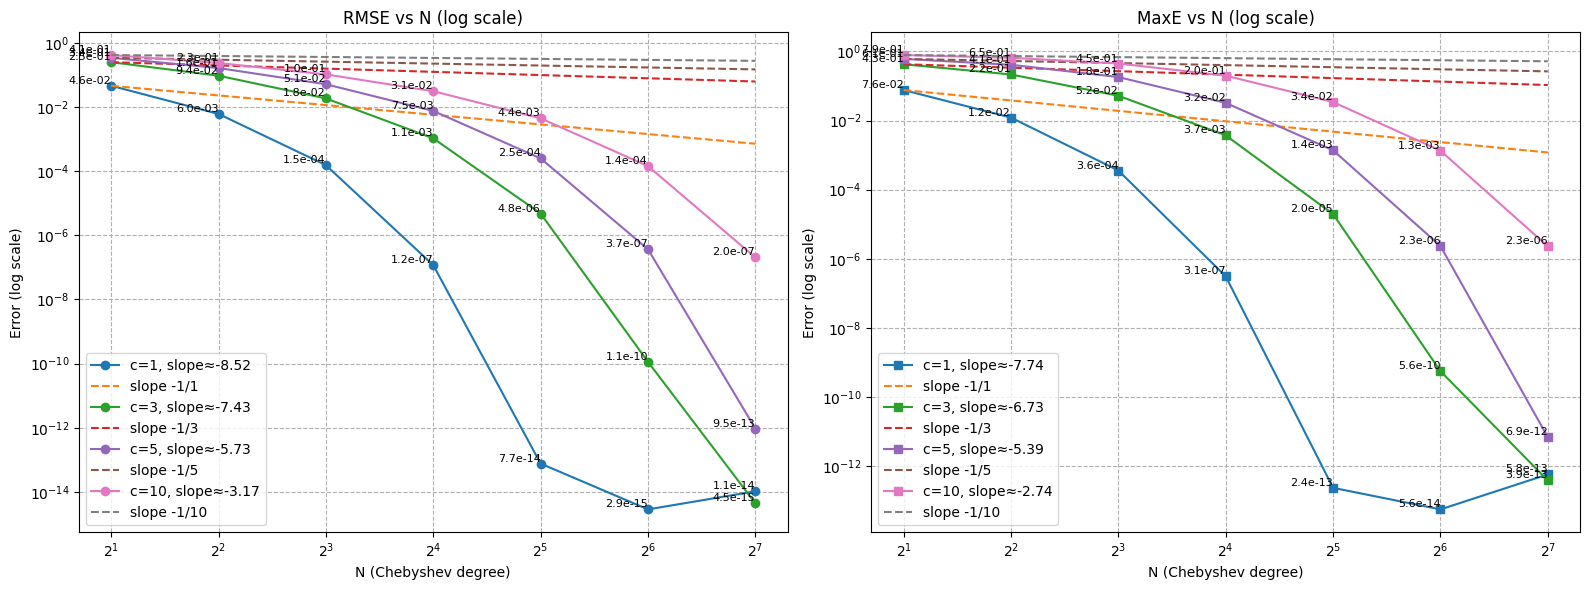

In [19]:
# Config
Ns = [2, 4, 8, 16, 32, 64, 128]
c_values = [1, 3, 5, 10]

# Prepare plots
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].set_title('RMSE vs N (log scale)')
axs[1].set_title('MaxE vs N (log scale)')

for c in c_values:
    rmse_list = []
    maxe_list = []

    print(f"\nResults for c = {c}:")
    
    for N in Ns:
        _, Z = chebyshev_2d_interpolation(N, c, resolution=100)
        F = compute_exact_function_grid(fcn, c, resolution=100)

        diff = F - Z
        rmse = np.sqrt(np.mean(diff**2))
        maxe = np.max(np.abs(diff))

        rmse_list.append(rmse)
        maxe_list.append(maxe)

        print(f"N = {N:>3} | RMSE = {rmse:.4e} | MaxE = {maxe:.4e}")

    # Plot RMSE
    axs[0].plot(Ns, rmse_list, marker='o', label=f'c={c}, slope≈{np.polyfit(np.log(Ns), np.log(rmse_list), 1)[0]:.2f}')
    for x, y in zip(Ns, rmse_list):
        axs[0].text(x, y, f'{y:.1e}', fontsize=8, ha='right', va='bottom')

    # Plot MaxE
    axs[1].plot(Ns, maxe_list, marker='s', label=f'c={c}, slope≈{np.polyfit(np.log(Ns), np.log(maxe_list), 1)[0]:.2f}')
    for x, y in zip(Ns, maxe_list):
        axs[1].text(x, y, f'{y:.1e}', fontsize=8, ha='right', va='bottom')

    # Reference lines
    x_ref = np.array(Ns)
    x0 = x_ref[0]
    y0_rmse = rmse_list[0]
    y0_maxe = maxe_list[0]

    ref_rmse = y0_rmse * (x_ref / x0) ** (-1 / c)
    ref_maxe = y0_maxe * (x_ref / x0) ** (-1 / c)

    axs[0].plot(x_ref, ref_rmse, '--', label=f'slope -1/{c}')
    axs[1].plot(x_ref, ref_maxe, '--', label=f'slope -1/{c}')

# Final plot formatting
for ax in axs:
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('N (Chebyshev degree)')
    ax.set_ylabel('Error (log scale)')
    ax.grid(True, which='both', linestyle='--')
    ax.legend()

plt.tight_layout()
plt.show()


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: divide by zero encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: overflow encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: invalid value encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)


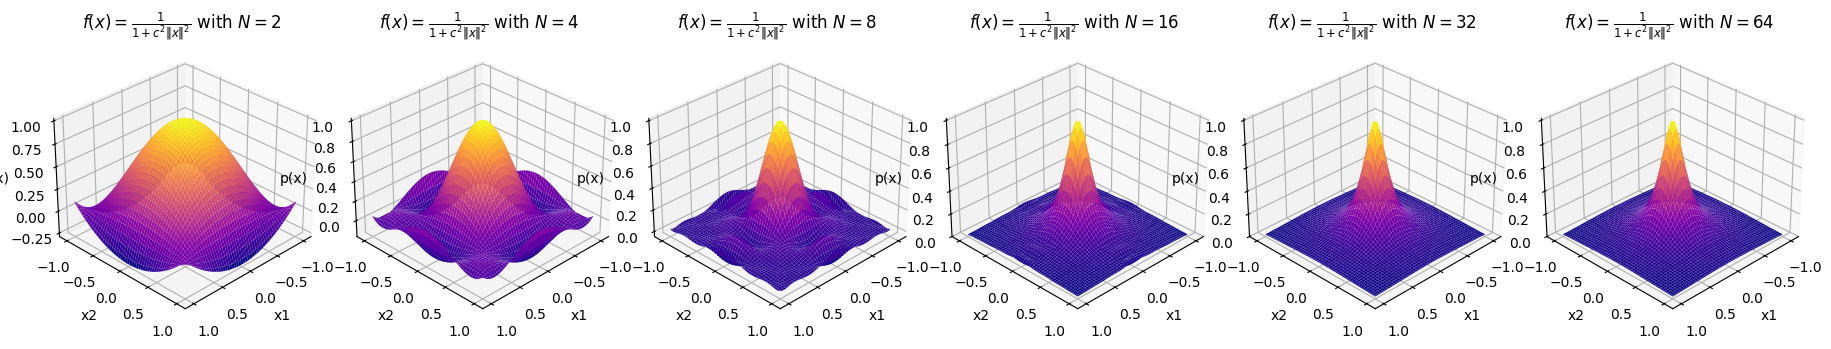

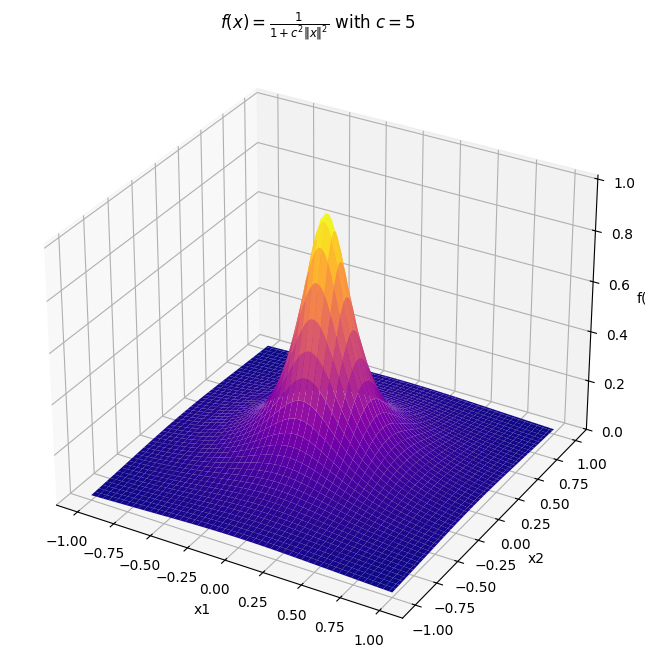

In [20]:
# Example usage of the function with c=5
Ns = [2, 4, 8, 16, 32, 64]
F = compute_exact_function_grid(fcn, 5, resolution=100)

# Create 3D plots for each c
fig = plt.figure(figsize=(18, 18))
for i, N in enumerate(Ns):
    c = 5
    C, Z = chebyshev_2d_interpolation(N, c, resolution=100)
    ax = fig.add_subplot(1, len(Ns), i+1, projection='3d')
    ax.plot_surface(X1, X2, Z, cmap='plasma', edgecolor='none')
    ax.set_title(rf'$f(x) = \frac{{1}}{{1 + c^2 \|x\|^2}}$' + f' with $N={N}$')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('p(x)')
    ax.view_init(30, 45)
plt.tight_layout()
plt.show()

# plot function values
X = np.linspace(-1, 1, 100)
Y = np.linspace(-1, 1, 100)
X, Y = np.meshgrid(X, Y)
plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, F, cmap='plasma', edgecolor='none')
ax.set_title(rf'$f(x) = \frac{{1}}{{1 + c^2 \|x\|^2}}$' + f' with $c=5$')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x)')
plt.show()

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/1947178225.py:10: RuntimeWarning: divide by zero encountered in matmul
  reconstructed = Uk @ Sk @ Vk
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/1947178225.py:10: RuntimeWarning: overflow encountered in matmul
  reconstructed = Uk @ Sk @ Vk
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/1947178225.py:10: RuntimeWarning: invalid value encountered in matmul
  reconstructed = Uk @ Sk @ Vk


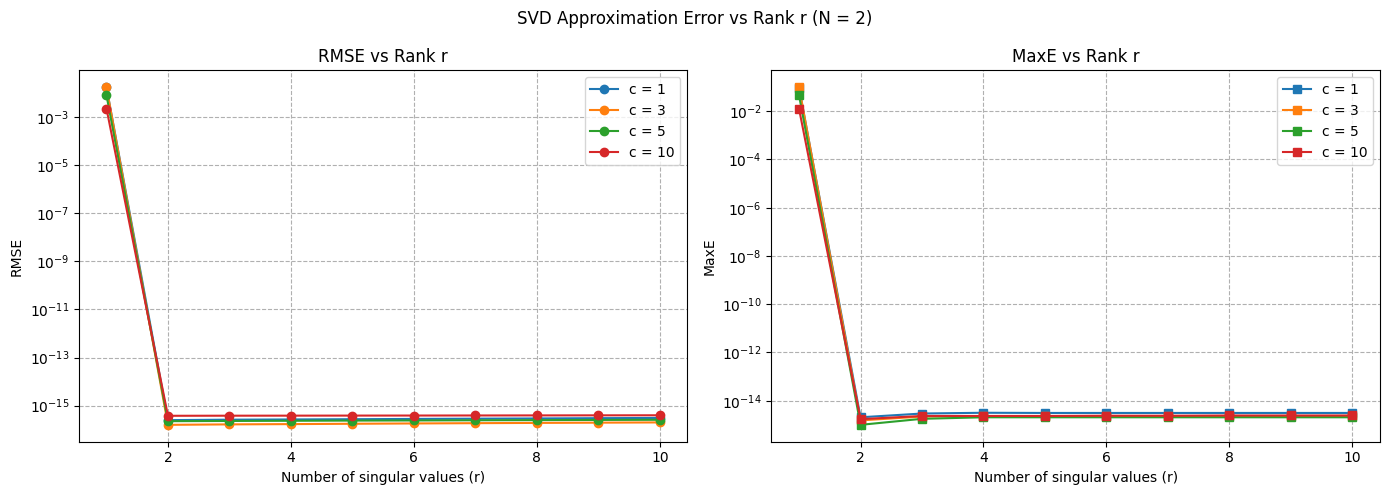

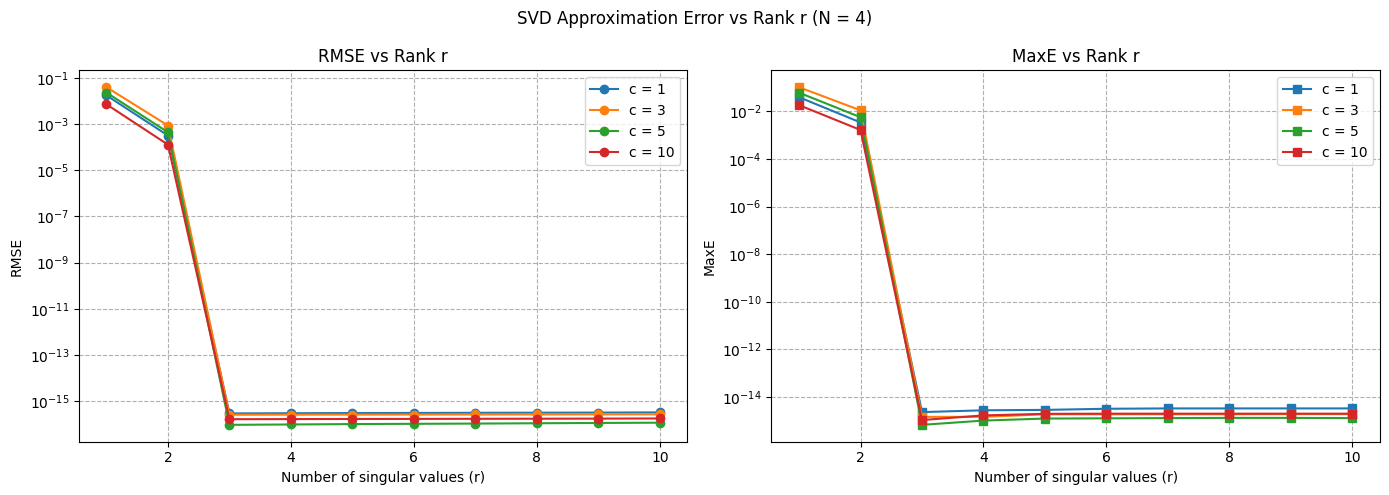

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: divide by zero encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: overflow encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: invalid value encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)


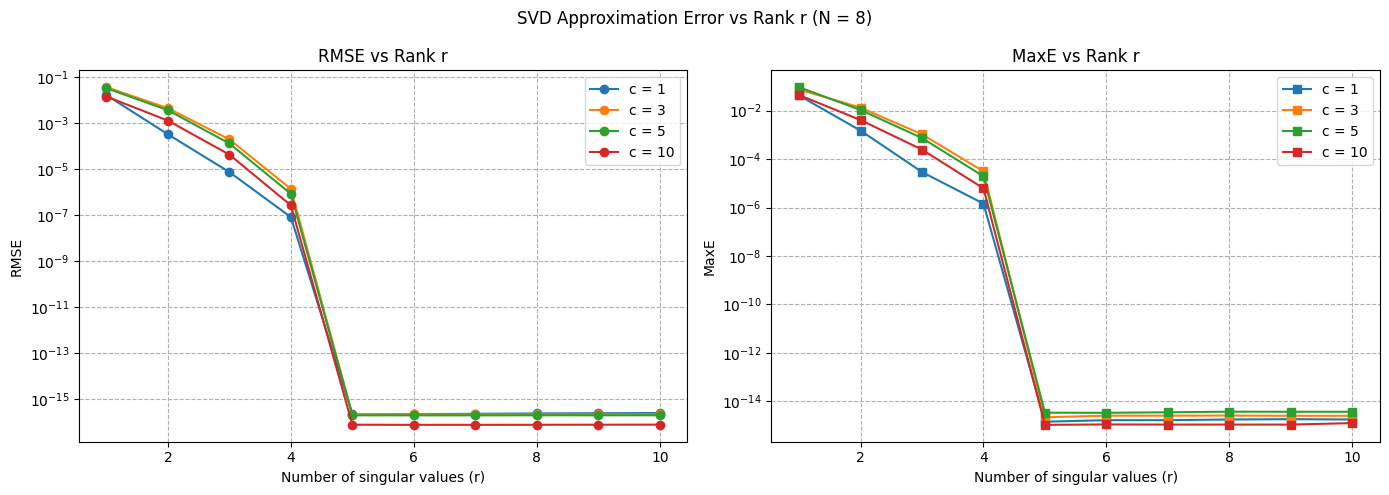

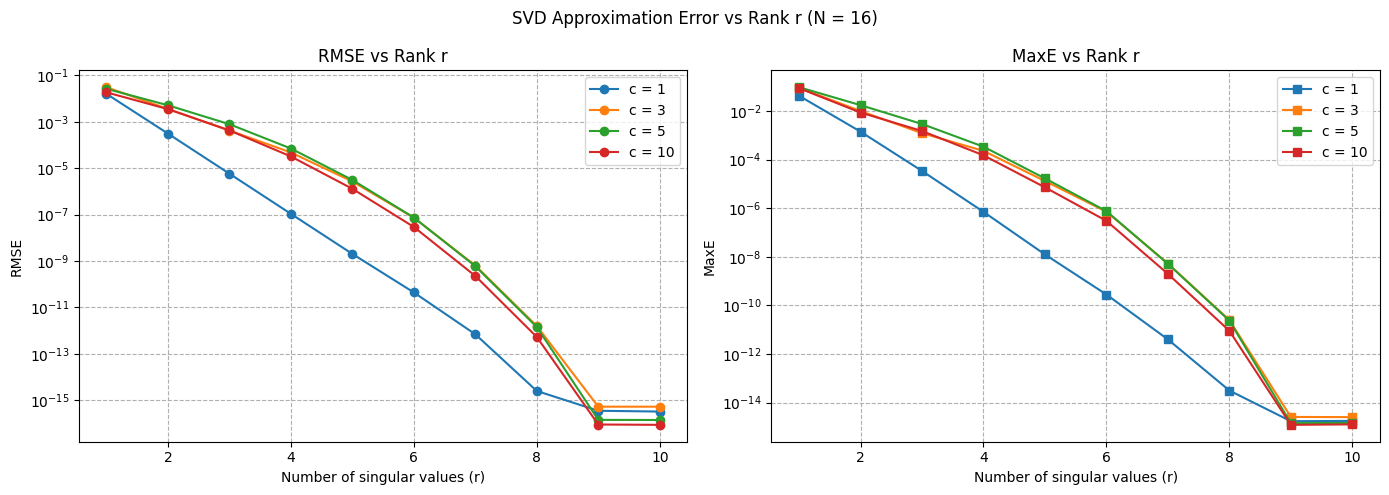

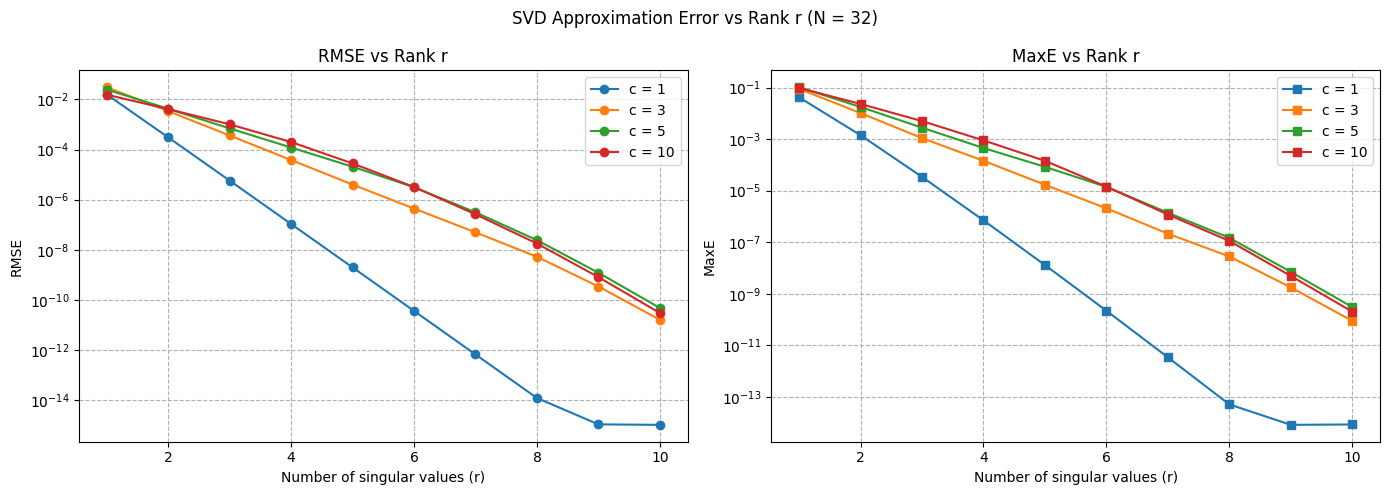

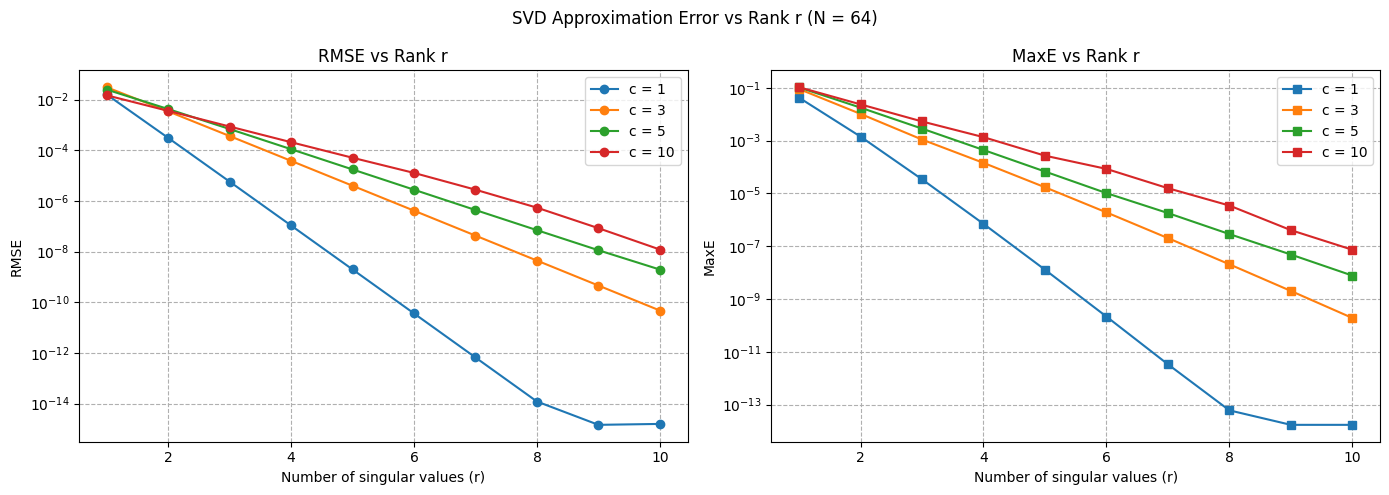

In [ ]:
Ns = [2, 4, 8, 16, 32, 64]
r = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
c_values = [1, 3, 5, 10]

def compute_svd_rmse_maxe(Z, r):
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    Uk = U[:, :r]
    Sk = np.diag(S[:r])
    Vk = Vt[:r, :]
    reconstructed = Uk @ Sk @ Vk
    diff = Z - reconstructed
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))
    return rmse, maxe

def plot_rmse_maxe_for_N(N, c_values, r_values):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'SVD Approximation Error vs Rank r (N = {N})')

    for c_val in c_values:
        _, Z = chebyshev_2d_interpolation(N, c_val, resolution=100)
        rmse_list = []
        maxe_list = []

        for r in r_values:
            rmse, maxe = compute_svd_rmse_maxe(Z, r)
            rmse_list.append(rmse)
            maxe_list.append(maxe)

        # Plot RMSE
        axs[0].plot(r_values, rmse_list, marker='o', label=f'c = {c_val}')
        # Plot MaxE
        axs[1].plot(r_values, maxe_list, marker='s', label=f'c = {c_val}')

    # Format RMSE plot 
    axs[0].set_xlabel('Number of singular values (r)')
    axs[0].set_ylabel('RMSE')
    axs[0].set_yscale('log')
    axs[0].set_title('RMSE vs Rank r')
    axs[0].grid(True, which='both', linestyle='--')
    axs[0].legend()

    # Format MaxE plot
    axs[1].set_xlabel('Number of singular values (r)')
    axs[1].set_ylabel('MaxE')
    axs[1].set_yscale('log')
    axs[1].set_title('MaxE vs Rank r')
    axs[1].grid(True, which='both', linestyle='--')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

# Generate a plot for each N
for N in Ns:
    plot_rmse_maxe_for_N(N, c_values, r)


--- Results for N = 2, c = 1 ---
r =  1 | SVD RMSE (Z-Zr): 1.753e+00, MaxE: 9.450e-02 | Interp RMSE (F-Zr): 4.794e-02, MaxE: 1.136e-01
r =  2 | SVD RMSE (Z-Zr): 2.488e-14, MaxE: 2.054e-15 | Interp RMSE (F-Zr): 4.567e-02, MaxE: 7.636e-02
r =  3 | SVD RMSE (Z-Zr): 2.596e-14, MaxE: 2.942e-15 | Interp RMSE (F-Zr): 4.567e-02, MaxE: 7.636e-02
r =  4 | SVD RMSE (Z-Zr): 2.654e-14, MaxE: 3.164e-15 | Interp RMSE (F-Zr): 4.567e-02, MaxE: 7.636e-02
r =  5 | SVD RMSE (Z-Zr): 2.717e-14, MaxE: 3.109e-15 | Interp RMSE (F-Zr): 4.567e-02, MaxE: 7.636e-02
r =  6 | SVD RMSE (Z-Zr): 2.791e-14, MaxE: 3.109e-15 | Interp RMSE (F-Zr): 4.567e-02, MaxE: 7.636e-02
r =  7 | SVD RMSE (Z-Zr): 2.857e-14, MaxE: 3.109e-15 | Interp RMSE (F-Zr): 4.567e-02, MaxE: 7.636e-02
r =  8 | SVD RMSE (Z-Zr): 2.920e-14, MaxE: 3.109e-15 | Interp RMSE (F-Zr): 4.567e-02, MaxE: 7.636e-02
r =  9 | SVD RMSE (Z-Zr): 3.000e-14, MaxE: 3.109e-15 | Interp RMSE (F-Zr): 4.567e-02, MaxE: 7.636e-02
r = 10 | SVD RMSE (Z-Zr): 3.069e-14, MaxE: 3.109

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/197289252.py:16: RuntimeWarning: divide by zero encountered in matmul
  reconstructed = Uk @ Sk @ Vk
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/197289252.py:16: RuntimeWarning: overflow encountered in matmul
  reconstructed = Uk @ Sk @ Vk
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/197289252.py:16: RuntimeWarning: invalid value encountered in matmul
  reconstructed = Uk @ Sk @ Vk


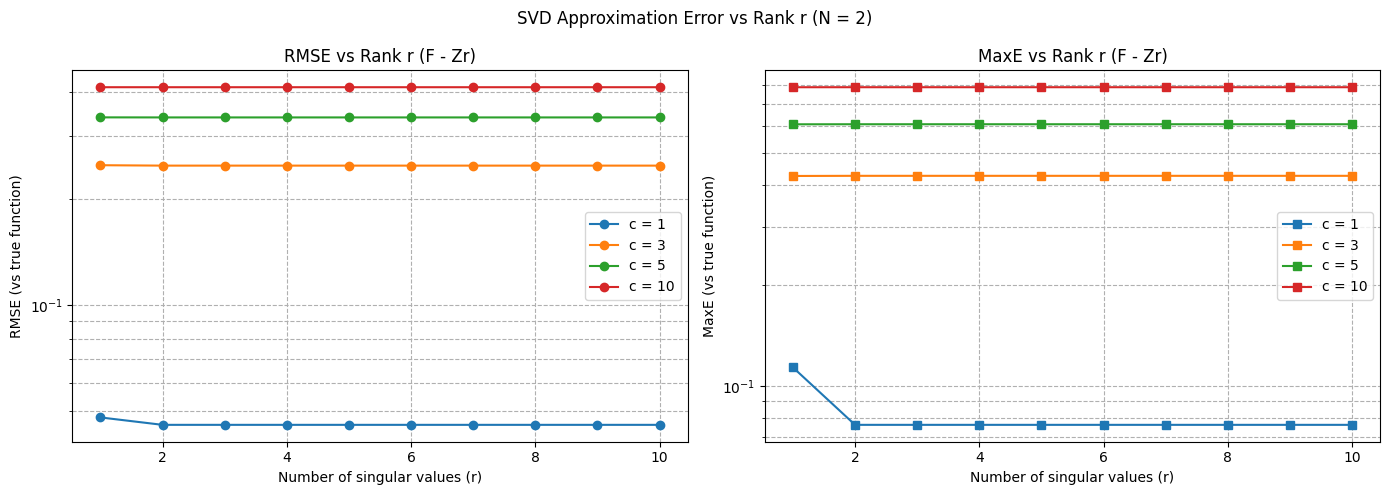


--- Results for N = 4, c = 1 ---
r =  1 | SVD RMSE (Z-Zr): 1.754e+00, MaxE: 3.921e-02 | Interp RMSE (F-Zr): 1.692e-02, MaxE: 4.111e-02
r =  2 | SVD RMSE (Z-Zr): 3.191e-02, MaxE: 3.417e-03 | Interp RMSE (F-Zr): 6.054e-03, MaxE: 1.186e-02
r =  3 | SVD RMSE (Z-Zr): 2.923e-14, MaxE: 2.331e-15 | Interp RMSE (F-Zr): 6.049e-03, MaxE: 1.219e-02
r =  4 | SVD RMSE (Z-Zr): 2.981e-14, MaxE: 2.776e-15 | Interp RMSE (F-Zr): 6.049e-03, MaxE: 1.219e-02
r =  5 | SVD RMSE (Z-Zr): 3.036e-14, MaxE: 2.887e-15 | Interp RMSE (F-Zr): 6.049e-03, MaxE: 1.219e-02
r =  6 | SVD RMSE (Z-Zr): 3.064e-14, MaxE: 3.220e-15 | Interp RMSE (F-Zr): 6.049e-03, MaxE: 1.219e-02
r =  7 | SVD RMSE (Z-Zr): 3.113e-14, MaxE: 3.331e-15 | Interp RMSE (F-Zr): 6.049e-03, MaxE: 1.219e-02
r =  8 | SVD RMSE (Z-Zr): 3.140e-14, MaxE: 3.331e-15 | Interp RMSE (F-Zr): 6.049e-03, MaxE: 1.219e-02
r =  9 | SVD RMSE (Z-Zr): 3.181e-14, MaxE: 3.331e-15 | Interp RMSE (F-Zr): 6.049e-03, MaxE: 1.219e-02
r = 10 | SVD RMSE (Z-Zr): 3.233e-14, MaxE: 3.331

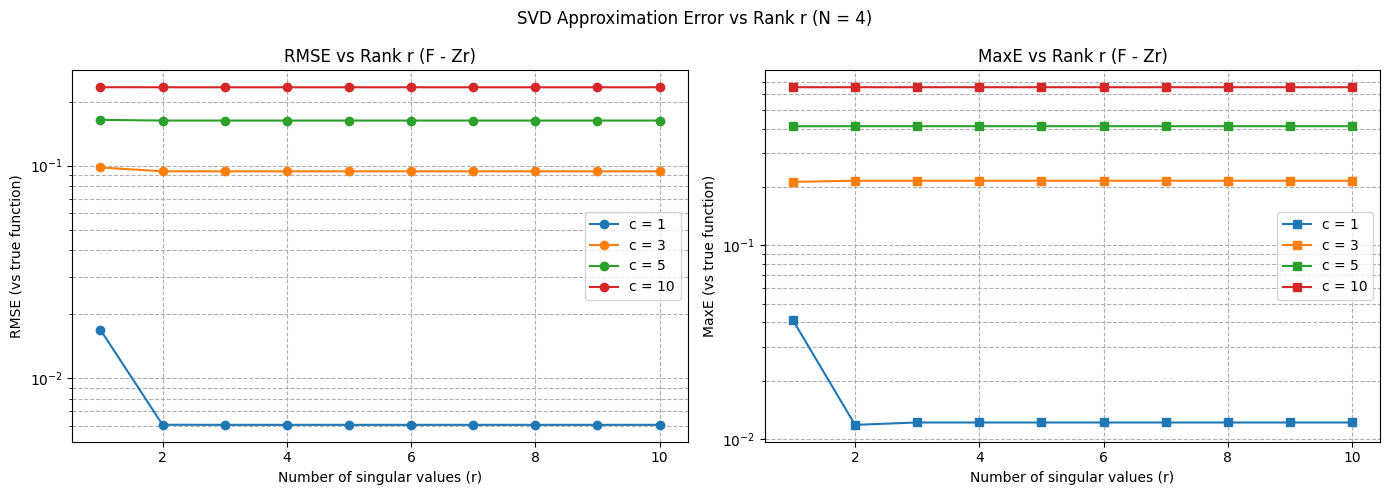


--- Results for N = 8, c = 1 ---
r =  1 | SVD RMSE (Z-Zr): 1.596e+00, MaxE: 4.240e-02 | Interp RMSE (F-Zr): 1.595e-02, MaxE: 4.236e-02
r =  2 | SVD RMSE (Z-Zr): 3.150e-02, MaxE: 1.506e-03 | Interp RMSE (F-Zr): 3.448e-04, MaxE: 1.472e-03
r =  3 | SVD RMSE (Z-Zr): 7.176e-04, MaxE: 2.933e-05 | Interp RMSE (F-Zr): 1.536e-04, MaxE: 3.732e-04
r =  4 | SVD RMSE (Z-Zr): 7.913e-06, MaxE: 1.448e-06 | Interp RMSE (F-Zr): 1.535e-04, MaxE: 3.586e-04
r =  5 | SVD RMSE (Z-Zr): 2.092e-14, MaxE: 1.443e-15 | Interp RMSE (F-Zr): 1.535e-04, MaxE: 3.588e-04
r =  6 | SVD RMSE (Z-Zr): 2.147e-14, MaxE: 1.665e-15 | Interp RMSE (F-Zr): 1.535e-04, MaxE: 3.588e-04
r =  7 | SVD RMSE (Z-Zr): 2.233e-14, MaxE: 1.665e-15 | Interp RMSE (F-Zr): 1.535e-04, MaxE: 3.588e-04
r =  8 | SVD RMSE (Z-Zr): 2.307e-14, MaxE: 1.776e-15 | Interp RMSE (F-Zr): 1.535e-04, MaxE: 3.588e-04
r =  9 | SVD RMSE (Z-Zr): 2.359e-14, MaxE: 1.832e-15 | Interp RMSE (F-Zr): 1.535e-04, MaxE: 3.588e-04
r = 10 | SVD RMSE (Z-Zr): 2.409e-14, MaxE: 1.776

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: divide by zero encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: overflow encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: invalid value encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/Users/loadedguns/Downloads/Research/Tensor_research/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/loadedguns/Downloads/Research/Tensor_research/.venv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/loadedguns/Downloads/Research/Tens

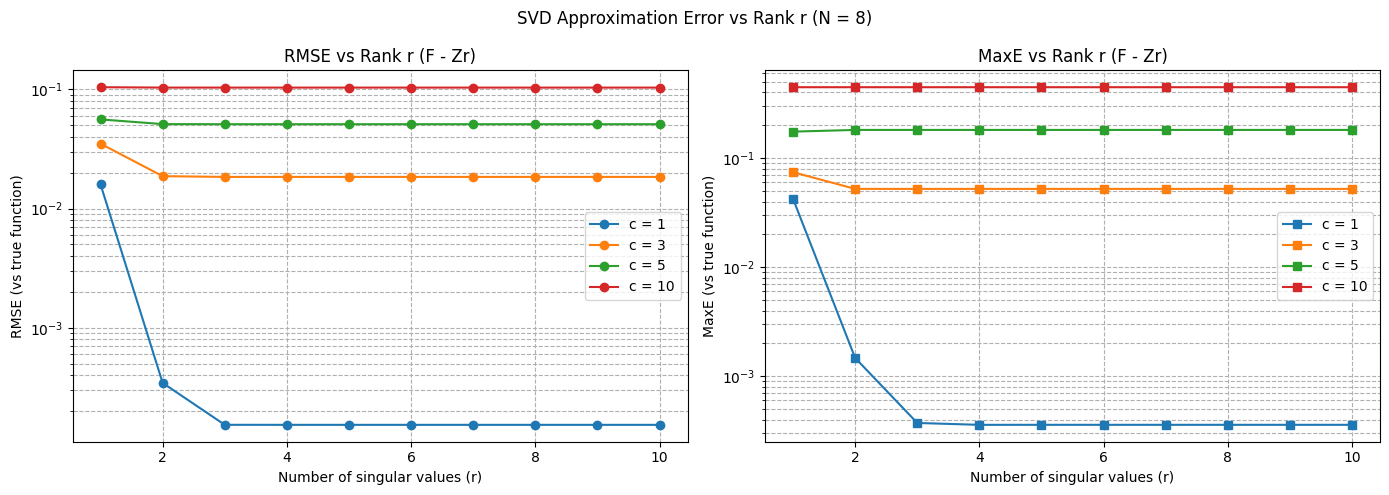


--- Results for N = 16, c = 1 ---
r =  1 | SVD RMSE (Z-Zr): 1.595e+00, MaxE: 4.260e-02 | Interp RMSE (F-Zr): 1.595e-02, MaxE: 4.260e-02
r =  2 | SVD RMSE (Z-Zr): 3.092e-02, MaxE: 1.426e-03 | Interp RMSE (F-Zr): 3.092e-04, MaxE: 1.426e-03
r =  3 | SVD RMSE (Z-Zr): 5.783e-04, MaxE: 3.442e-05 | Interp RMSE (F-Zr): 5.785e-06, MaxE: 3.442e-05
r =  4 | SVD RMSE (Z-Zr): 1.073e-05, MaxE: 7.128e-07 | Interp RMSE (F-Zr): 1.589e-07, MaxE: 7.095e-07
r =  5 | SVD RMSE (Z-Zr): 2.008e-07, MaxE: 1.259e-08 | Interp RMSE (F-Zr): 1.175e-07, MaxE: 3.170e-07
r =  6 | SVD RMSE (Z-Zr): 4.377e-09, MaxE: 2.819e-10 | Interp RMSE (F-Zr): 1.175e-07, MaxE: 3.107e-07
r =  7 | SVD RMSE (Z-Zr): 6.874e-11, MaxE: 4.002e-12 | Interp RMSE (F-Zr): 1.175e-07, MaxE: 3.108e-07
r =  8 | SVD RMSE (Z-Zr): 2.477e-13, MaxE: 3.153e-14 | Interp RMSE (F-Zr): 1.175e-07, MaxE: 3.108e-07
r =  9 | SVD RMSE (Z-Zr): 3.469e-14, MaxE: 1.721e-15 | Interp RMSE (F-Zr): 1.175e-07, MaxE: 3.108e-07
r = 10 | SVD RMSE (Z-Zr): 3.211e-14, MaxE: 1.77

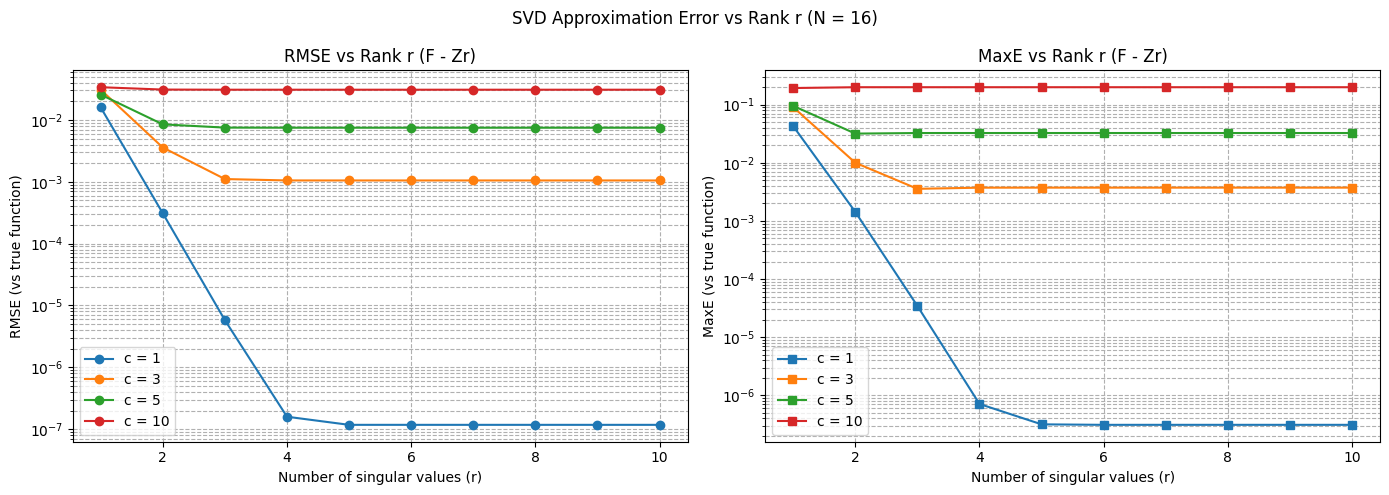


--- Results for N = 32, c = 1 ---
r =  1 | SVD RMSE (Z-Zr): 1.595e+00, MaxE: 4.260e-02 | Interp RMSE (F-Zr): 1.595e-02, MaxE: 4.260e-02
r =  2 | SVD RMSE (Z-Zr): 3.092e-02, MaxE: 1.426e-03 | Interp RMSE (F-Zr): 3.092e-04, MaxE: 1.426e-03
r =  3 | SVD RMSE (Z-Zr): 5.784e-04, MaxE: 3.445e-05 | Interp RMSE (F-Zr): 5.784e-06, MaxE: 3.445e-05
r =  4 | SVD RMSE (Z-Zr): 1.070e-05, MaxE: 7.074e-07 | Interp RMSE (F-Zr): 1.070e-07, MaxE: 7.074e-07
r =  5 | SVD RMSE (Z-Zr): 1.969e-07, MaxE: 1.299e-08 | Interp RMSE (F-Zr): 1.969e-09, MaxE: 1.299e-08
r =  6 | SVD RMSE (Z-Zr): 3.606e-09, MaxE: 2.179e-10 | Interp RMSE (F-Zr): 3.606e-11, MaxE: 2.179e-10
r =  7 | SVD RMSE (Z-Zr): 6.573e-11, MaxE: 3.382e-12 | Interp RMSE (F-Zr): 6.618e-13, MaxE: 3.383e-12
r =  8 | SVD RMSE (Z-Zr): 1.197e-12, MaxE: 5.029e-14 | Interp RMSE (F-Zr): 7.801e-14, MaxE: 2.360e-13
r =  9 | SVD RMSE (Z-Zr): 1.061e-13, MaxE: 8.105e-15 | Interp RMSE (F-Zr): 7.709e-14, MaxE: 2.409e-13
r = 10 | SVD RMSE (Z-Zr): 1.017e-13, MaxE: 8.38

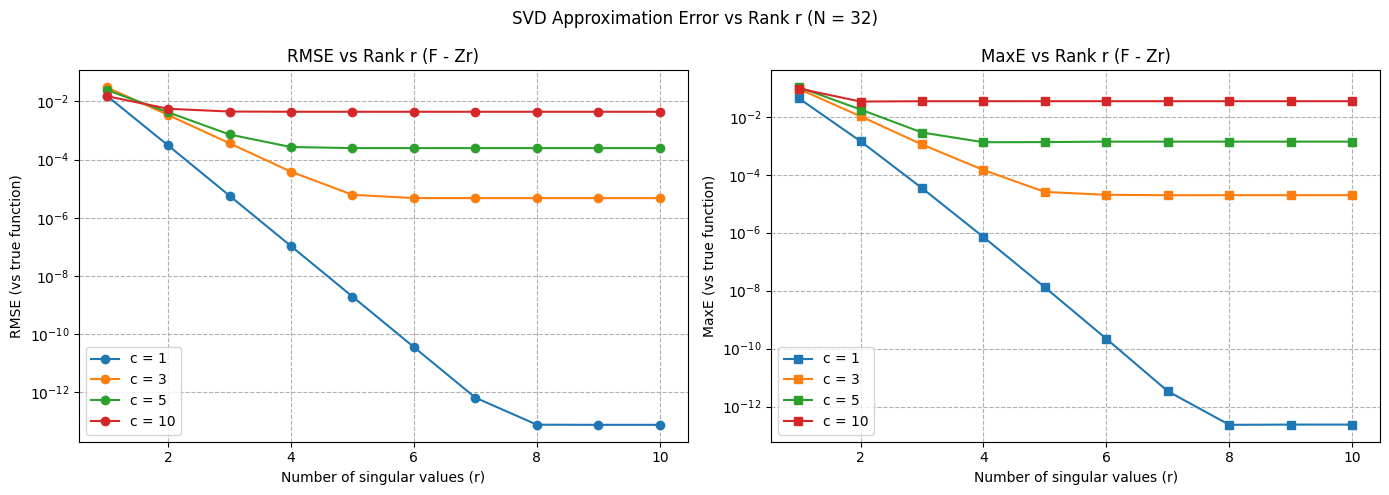


--- Results for N = 64, c = 1 ---
r =  1 | SVD RMSE (Z-Zr): 1.595e+00, MaxE: 4.260e-02 | Interp RMSE (F-Zr): 1.595e-02, MaxE: 4.260e-02
r =  2 | SVD RMSE (Z-Zr): 3.092e-02, MaxE: 1.426e-03 | Interp RMSE (F-Zr): 3.092e-04, MaxE: 1.426e-03
r =  3 | SVD RMSE (Z-Zr): 5.784e-04, MaxE: 3.445e-05 | Interp RMSE (F-Zr): 5.784e-06, MaxE: 3.445e-05
r =  4 | SVD RMSE (Z-Zr): 1.070e-05, MaxE: 7.074e-07 | Interp RMSE (F-Zr): 1.070e-07, MaxE: 7.074e-07
r =  5 | SVD RMSE (Z-Zr): 1.969e-07, MaxE: 1.299e-08 | Interp RMSE (F-Zr): 1.969e-09, MaxE: 1.299e-08
r =  6 | SVD RMSE (Z-Zr): 3.606e-09, MaxE: 2.180e-10 | Interp RMSE (F-Zr): 3.606e-11, MaxE: 2.180e-10
r =  7 | SVD RMSE (Z-Zr): 6.573e-11, MaxE: 3.395e-12 | Interp RMSE (F-Zr): 6.573e-13, MaxE: 3.414e-12
r =  8 | SVD RMSE (Z-Zr): 1.198e-12, MaxE: 6.106e-14 | Interp RMSE (F-Zr): 1.228e-14, MaxE: 8.316e-14
r =  9 | SVD RMSE (Z-Zr): 1.439e-13, MaxE: 1.726e-14 | Interp RMSE (F-Zr): 2.939e-15, MaxE: 3.886e-14
r = 10 | SVD RMSE (Z-Zr): 1.565e-13, MaxE: 1.72

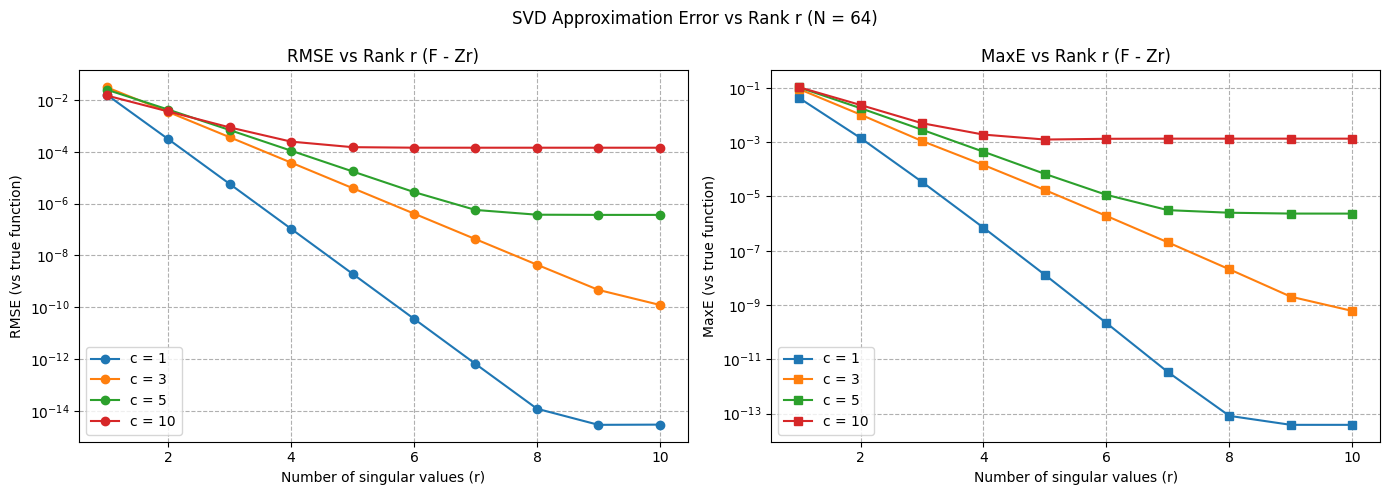

In [28]:
# NEW CODE 



N = 32

Ns = [2, 4, 8, 16, 32, 64]
r_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
c_values = [1, 3, 5, 10]

def compute_svd_rmse_maxe(Z, F, r):
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    Uk = U[:, :r]
    Sk = np.diag(S[:r])
    Vk = Vt[:r, :]
    reconstructed = Uk @ Sk @ Vk

    # SVD reconstruction error (Z - Z_recon)
    diff_recon = Z - reconstructed
    l2_error = np.linalg.norm(diff_recon)
    maxe_recon = np.max(np.abs(diff_recon))

    # Interpolation error with true function (F - Z_recon)
    diff_func = F - reconstructed
    rmse_func = np.sqrt(np.mean(diff_func**2))
    maxe_func = np.max(np.abs(diff_func))

    return l2_error, maxe_recon, rmse_func, maxe_func

def plot_rmse_maxe_for_N(N, c_values, r_values):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'SVD Approximation Error vs Rank r (N = {N})')

    for c_val in c_values:
        _, Z = chebyshev_2d_interpolation(N, c_val, resolution=100)
        F = compute_exact_function_grid(fcn, c_val, resolution=100)

        l2_error_list = []
        rmse_func_list = []
        maxe_func_list = []

        print(f"\n--- Results for N = {N}, c = {c_val} ---")
        for r in r_values:
            l2_error, maxe_recon, rmse_func, maxe_func = compute_svd_rmse_maxe(Z, F, r)
            l2_error_list.append(l2_error)
            rmse_func_list.append(rmse_func)
            maxe_func_list.append(maxe_func)

            print(f"r = {r:2d} | SVD RMSE (Z-Zr): {l2_error:.3e}, MaxE: {maxe_recon:.3e} | "
                  f"Interp RMSE (F-Zr): {rmse_func:.3e}, MaxE: {maxe_func:.3e}")

        # Plot RMSE (vs function)
        axs[0].plot(r_values, rmse_func_list, marker='o', label=f'c = {c_val}')
        # Plot MaxE (vs function)
        axs[1].plot(r_values, maxe_func_list, marker='s', label=f'c = {c_val}')

    # Format RMSE plot
    axs[0].set_xlabel('Number of singular values (r)')
    axs[0].set_ylabel('RMSE (vs true function)')
    axs[0].set_yscale('log')
    axs[0].set_title('RMSE vs Rank r (F - Zr)')
    axs[0].grid(True, which='both', linestyle='--')
    axs[0].legend()

    # Format MaxE plot
    axs[1].set_xlabel('Number of singular values (r)')
    axs[1].set_ylabel('MaxE (vs true function)')
    axs[1].set_yscale('log')
    axs[1].set_title('MaxE vs Rank r (F - Zr)')
    axs[1].grid(True, which='both', linestyle='--')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

# Generate a plot and print values for each N
for N in Ns:
    plot_rmse_maxe_for_N(N, c_values, r_values)




In [22]:
Ns = [2, 4, 8, 16, 32, 64]

# print the first five singular values for c=5 and different N
def print_singular_values(N, c):
    C, Z = chebyshev_2d_interpolation(N, c, resolution=100)
    U, S, Vt = np.linalg.svd(C, full_matrices=False)
    print(f"Singular values for N={N}, c={c}: {S[:5]}")

for N in Ns:
    print_singular_values(N, 5)

Singular values for N=2, c=5: [5.36755843e-01 1.93842194e-02 4.89431370e-17]
Singular values for N=4, c=5: [3.43856032e-01 2.96541765e-02 2.05564701e-03 2.92714923e-17
 2.39417120e-17]
Singular values for N=8, c=5: [2.14444858e-01 3.73339683e-02 7.39467874e-03 3.71735730e-04
 3.76980202e-06]
Singular values for N=16, c=5: [1.76730429e-01 3.12863760e-02 8.54953034e-03 1.56378424e-03
 1.53038374e-04]
Singular values for N=32, c=5: [0.17490858 0.02999718 0.0072919  0.00126471 0.00021112]


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: divide by zero encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: overflow encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: invalid value encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)


Singular values for N=64, c=5: [0.17490491 0.0299929  0.00728286 0.00125066 0.00019803]


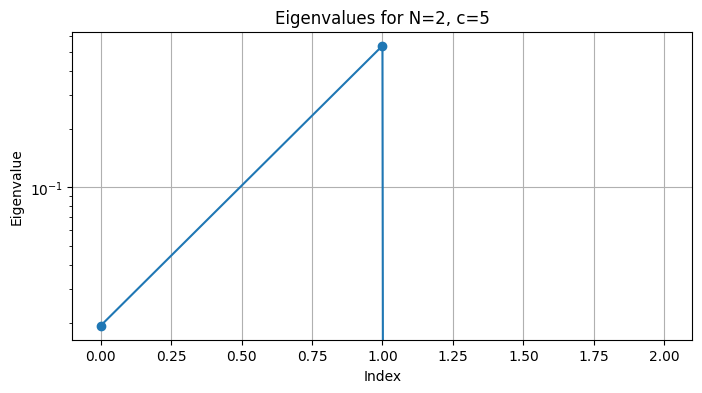

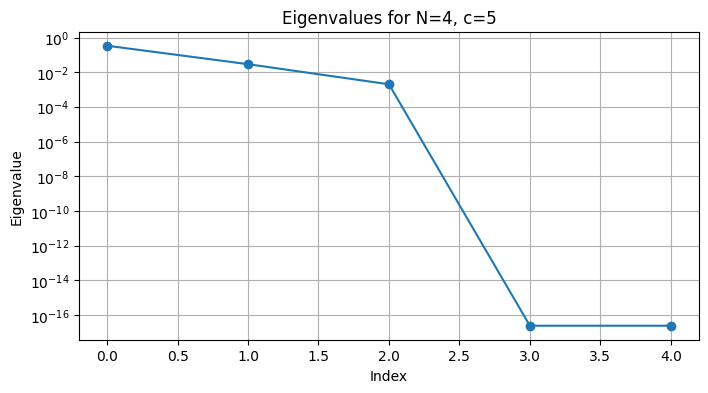

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: divide by zero encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: overflow encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: invalid value encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)


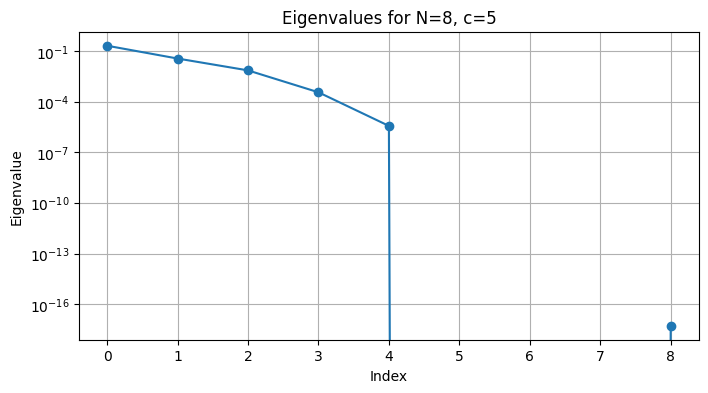

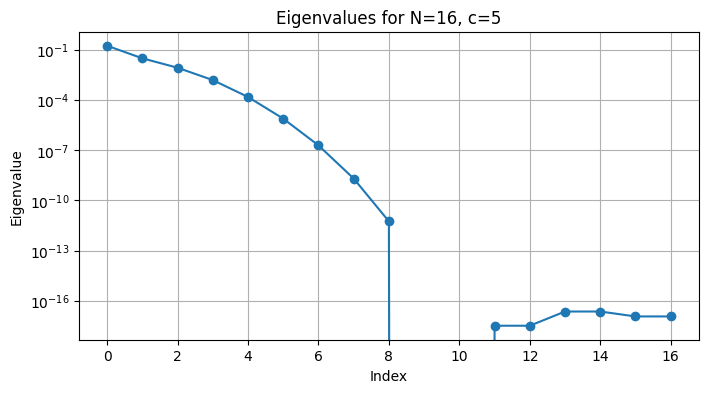

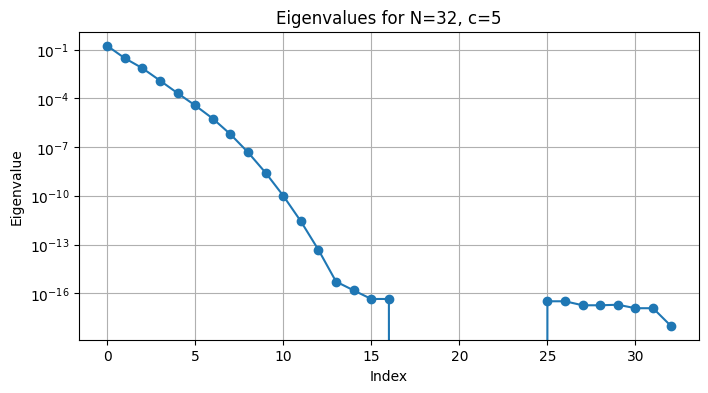

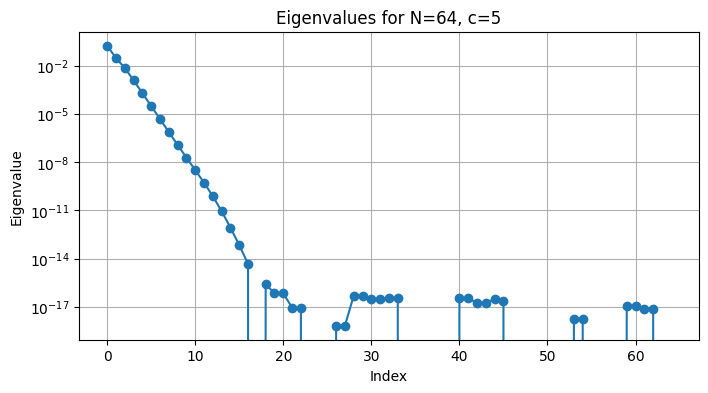

In [23]:
# use eigen value decomposition to compute the eigenvalues of C
def compute_eigenvalues(C):
    eigenvalues, _ = np.linalg.eig(C)
    return eigenvalues

def plot_eigenvalues(N, c):
    C, Z = chebyshev_2d_interpolation(N, c, resolution=100)
    eigenvalues = compute_eigenvalues(C)
    eigenvalues = np.real(eigenvalues)
    plt.figure(figsize=(8, 4))
    plt.plot(eigenvalues, marker='o')
    plt.title(f'Eigenvalues for N={N}, c={c}')
    plt.yscale('log')
    plt.xlabel('Index')
    plt.ylabel('Eigenvalue')
    plt.grid(True)
    plt.show()

for N in Ns:
    plot_eigenvalues(N, 5)


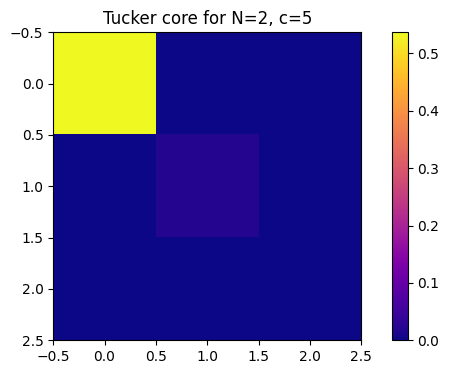

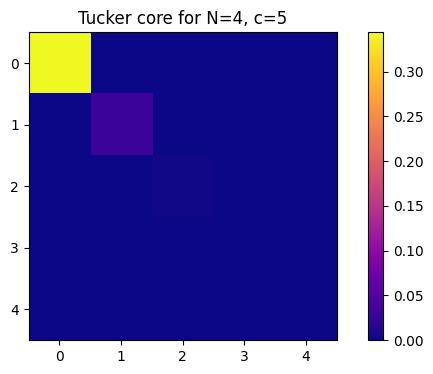

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: divide by zero encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: overflow encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: invalid value encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)


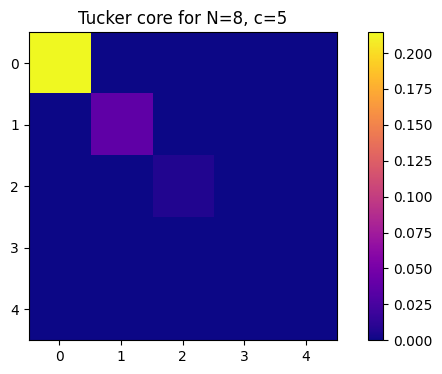

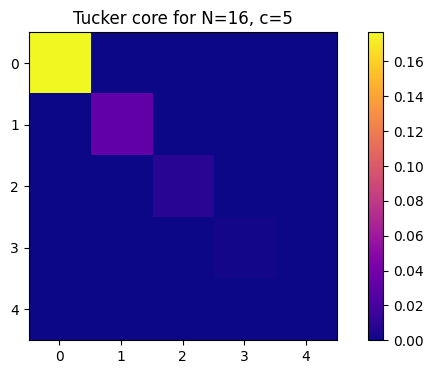

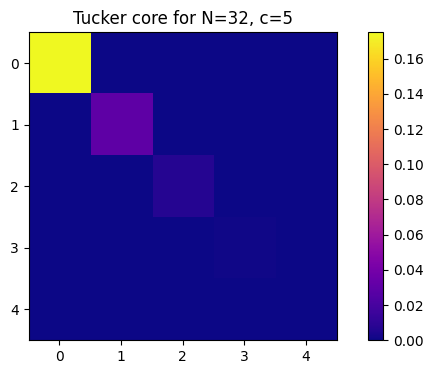

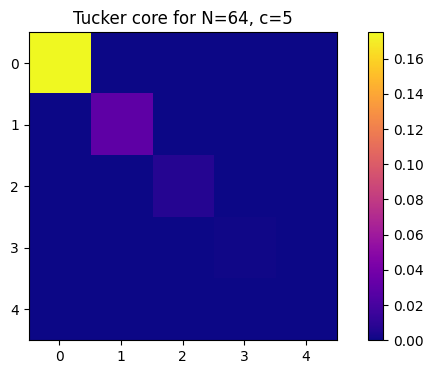

In [24]:
# tucker decomposition
from tensorly.decomposition import tucker
def compute_tucker_decomposition(C, rank):
    core, factors = tucker(C, rank=rank)
    return core, factors

# plot the core tensor for c=5 and different N
def plot_tucker_core(N, c, rank):
    C, Z = chebyshev_2d_interpolation(N, c, resolution=100)
    core, factors = compute_tucker_decomposition(C, rank)
    plt.figure(figsize=(8, 4))
    plt.imshow(core, cmap='plasma')
    plt.title(f'Tucker core for N={N}, c={c}')
    plt.colorbar()
    plt.show()

for N in Ns:
    plot_tucker_core(N, 5, rank=5)

/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: divide by zero encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: overflow encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_36653/3840703463.py:25: RuntimeWarning: invalid value encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)


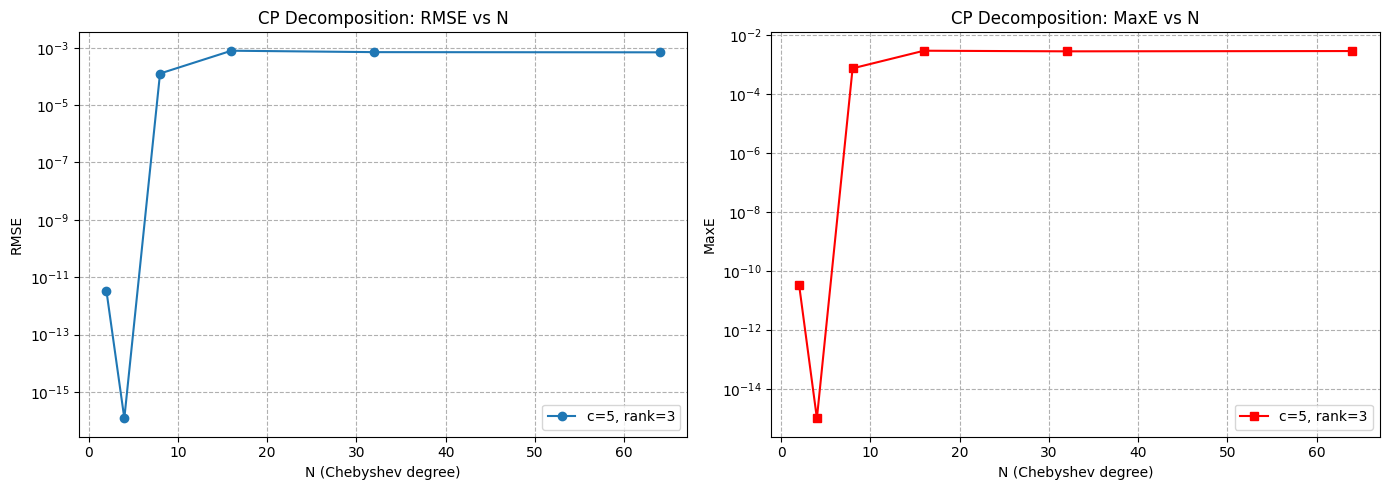

In [25]:
from tensorly.decomposition import parafac
from tensorly import cp_to_tensor
from numpy.linalg import norm
import matplotlib.pyplot as plt

c_val = 5
rank = 3

def compute_cp_decomposition(C, rank):
    weights, factors = parafac(C, rank=rank)
    return weights, factors

def compute_cp_rmse_maxe(N, c, rank):
    _, C = chebyshev_2d_interpolation(N, c, resolution=100)
    weights, factors = compute_cp_decomposition(C, rank)
    C_approx = cp_to_tensor((weights, factors))

    diff = C - C_approx
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    return rmse, maxe

# Store errors
rmse_list = []
maxe_list = []

for N in Ns:
    rmse, maxe = compute_cp_rmse_maxe(N, c=c_val, rank=rank)
    rmse_list.append(rmse)
    maxe_list.append(maxe)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# RMSE plot
axs[0].plot(Ns, rmse_list, marker='o', label=f'c={c_val}, rank={rank}')
axs[0].set_yscale('log')
axs[0].set_xlabel('N (Chebyshev degree)')
axs[0].set_ylabel('RMSE')
axs[0].set_title('CP Decomposition: RMSE vs N')
axs[0].grid(True, which='both', linestyle='--')
axs[0].legend()

# MaxE plot
axs[1].plot(Ns, maxe_list, marker='s', color='red', label=f'c={c_val}, rank={rank}')
axs[1].set_yscale('log')
axs[1].set_xlabel('N (Chebyshev degree)')
axs[1].set_ylabel('MaxE')
axs[1].set_title('CP Decomposition: MaxE vs N')
axs[1].grid(True, which='both', linestyle='--')
axs[1].legend()

plt.tight_layout()
plt.show()